In [9]:
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
import seaborn as sns

# Load .arff file (update the path if needed)
file_path = r"B:\action-leaning\ml\dataset\final-dataset.arff"
data, meta = arff.loadarff(file_path)

# Convert to DataFrame
df = pd.DataFrame(data)

# Decode byte strings to regular strings
for col in df.select_dtypes([object]).columns:
    try:
        df[col] = df[col].str.decode('utf-8')
    except AttributeError:
        pass

df.head()


,SRC_ADD,DES_ADD,PKT_ID,FROM_NODE,TO_NODE,PKT_TYPE,PKT_SIZE,FLAGS,FID,SEQ_NUMBER,...,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED,PKT_CLASS
0,3.00,24.30,389693.0,21.0,23.0,tcp,1540.0,-------,4.0,11339.0,...,328.240918,505490.0,1540.0,0.236321,0.0,35.519662,35.550032,1.000000,50.021920,Normal
1,15.00,24.15,201196.0,23.0,24.0,tcp,1540.0,-------,16.0,6274.0,...,328.205808,505437.0,1540.0,0.236337,0.0,20.156478,20.186848,1.000000,50.030211,Normal
2,24.15,15.00,61905.0,23.0,22.0,ack,55.0,-------,16.0,1930.0,...,328.206042,18051.3,55.0,0.008441,0.0,7.039952,7.069962,1.030045,50.060221,UDP-Flood
3,24.90,9.00,443135.0,23.0,21.0,ack,55.0,-------,10.0,12670.0,...,328.064183,18043.5,55.0,0.008437,0.0,39.617967,39.647976,1.030058,50.060098,Normal
4,24.80,8.00,157335.0,23.0,21.0,ack,55.0,-------,9.0,4901.0,...,328.113525,18046.2,55.0,0.008438,0.0,16.029803,16.059813,1.030054,50.061864,Normal


In [5]:
# Shape and data info
print(f"Dataset shape: {df.shape}")
print(df.info())

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check label distribution
print("Class distribution:\n", df['PKT_CLASS'].value_counts())


Dataset shape: (2160668, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2160668 entries, 0 to 2160667
Data columns (total 28 columns):
 #   Column            Dtype  
---  ------            -----  
 0   SRC_ADD           float64
 1   DES_ADD           float64
 2   PKT_ID            float64
 3   FROM_NODE         float64
 4   TO_NODE           float64
 5   PKT_TYPE          object 
 6   PKT_SIZE          float64
 7   FLAGS             object 
 8   FID               float64
 9   SEQ_NUMBER        float64
 10  NUMBER_OF_PKT     float64
 11  NUMBER_OF_BYTE    float64
 12  NODE_NAME_FROM    object 
 13  NODE_NAME_TO      object 
 14  PKT_IN            float64
 15  PKT_OUT           float64
 16  PKT_R             float64
 17  PKT_DELAY_NODE    float64
 18  PKT_RATE          float64
 19  BYTE_RATE         float64
 20  PKT_AVG_SIZE      float64
 21  UTILIZATION       float64
 22  PKT_DELAY         float64
 23  PKT_SEND_TIME     float64
 24  PKT_RESEVED_TIME  float64
 25  FIRST_PKT_SENT  

In [6]:
# Check class labels that include HTTP flood
http_keywords = ['http', 'flood']
df['PKT_CLASS'] = df['PKT_CLASS'].str.lower()

# Keep rows where label is 'normal' or contains 'http'
df_filtered = df[df['PKT_CLASS'].str.contains('http') | (df['PKT_CLASS'] == 'normal')]

print("Filtered class distribution:\n", df_filtered['PKT_CLASS'].value_counts())


Filtered class distribution:
 PKT_CLASS
normal        1935959
http-flood       4110
Name: count, dtype: int64


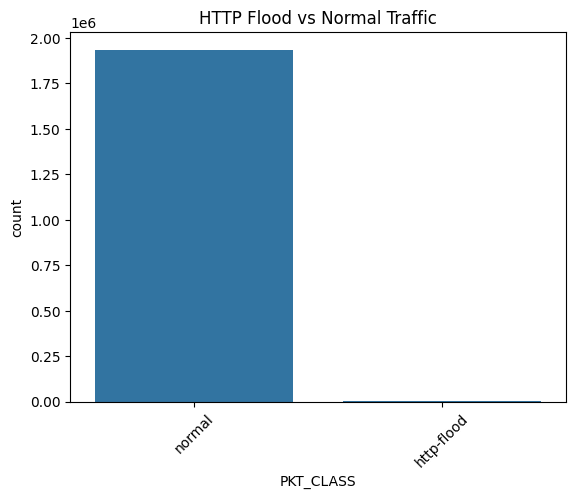

In [7]:
sns.countplot(data=df_filtered, x='PKT_CLASS')
plt.xticks(rotation=45)
plt.title("HTTP Flood vs Normal Traffic")
plt.show()


In [8]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_filtered.copy()

# Convert all object columns except 'PKT_CLASS'
categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('PKT_CLASS')

encoder = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

# Encode the class column as binary (0 = normal, 1 = http flood)
df_encoded['label'] = df_encoded['PKT_CLASS'].apply(lambda x: 0 if x == 'normal' else 1)
df_encoded.drop(columns=['PKT_CLASS'], inplace=True)

df_encoded.head()


,SRC_ADD,DES_ADD,PKT_ID,FROM_NODE,TO_NODE,PKT_TYPE,PKT_SIZE,FLAGS,FID,SEQ_NUMBER,...,PKT_RATE,BYTE_RATE,PKT_AVG_SIZE,UTILIZATION,PKT_DELAY,PKT_SEND_TIME,PKT_RESEVED_TIME,FIRST_PKT_SENT,LAST_PKT_RESEVED,label
0,3.0,24.30,389693.0,21.0,23.0,3,1540.0,0,4.0,11339.0,...,328.240918,505490.0,1540.0,0.236321,0.0,35.519662,35.550032,1.000000,50.021920,0
1,15.0,24.15,201196.0,23.0,24.0,3,1540.0,0,16.0,6274.0,...,328.205808,505437.0,1540.0,0.236337,0.0,20.156478,20.186848,1.000000,50.030211,0
3,24.9,9.00,443135.0,23.0,21.0,0,55.0,0,10.0,12670.0,...,328.064183,18043.5,55.0,0.008437,0.0,39.617967,39.647976,1.030058,50.060098,0
4,24.8,8.00,157335.0,23.0,21.0,0,55.0,0,9.0,4901.0,...,328.113525,18046.2,55.0,0.008438,0.0,16.029803,16.059813,1.030054,50.061864,0
5,24.1,1.00,219350.0,21.0,1.0,0,55.0,0,2.0,6837.0,...,328.297902,18056.4,55.0,0.008440,0.0,21.865762,21.895771,1.030016,50.043427,0


In [9]:
df_encoded.to_csv("http_flood_data_cleaned.csv", index=False)
print("✅ Cleaned data saved as 'http_flood_data_cleaned.csv'")

✅ Cleaned data saved as 'http_flood_data_cleaned.csv'
